In [23]:
import pandas as pd
import random

breeds_sizes = [
    ("Labrador Retriever", "large"),
    ("Golden Retriever", "large"),
    ("German Shepherd", "large"),
    ("Rottweiler", "large"),
    ("Great Dane", "large"),
    ("Doberman Pinscher", "large"),
    ("Siberian Husky", "medium"),
    ("Bulldog", "medium"),
    ("Boxer", "medium"),
    ("Australian Shepherd", "medium"),
    ("Border Collie", "medium"),
    ("Beagle", "small"),
    ("Dachshund", "small"),
    ("Poodle", "small"),
    ("Chihuahua", "small"),
    ("French Bulldog", "small"),
    ("Yorkshire Terrier", "small"),
    ("Shih Tzu", "small"),
    ("Maltese", "small"),
    ("Pomeranian", "small"),
    ("French Griffon", "small")
]

genders = ["Male", "Female"]

num_rows = 2500

username_list = random.sample(range(1000, 25000), num_rows)

data = {
    "username": [],
    "pet_breed": [],
    "age": [],
    "size": [],
    "gender": [],
    "latitude": [],
    "longitude": []
}

for i in range(num_rows):
    # Pick a random breed-size pair
    breed, size = random.choice(breeds_sizes)
    
    # Random age between 1 and 15
    age = random.randint(1, 15)
    
    # Random gender
    gender = random.choice(genders)
    
    # Random geographic coordinates in Egypt
    lat = random.uniform(22.0, 31.0)
    lon = random.uniform(25.0, 36.0)
    
    data["username"].append(username_list[i])
    data["pet_breed"].append(breed)
    data["age"].append(age)
    data["size"].append(size)
    data["gender"].append(gender)
    data["latitude"].append(lat)
    data["longitude"].append(lon)

df = pd.DataFrame(data)

df.to_csv("petProfiles10k.csv", index=False)

# Show a small sample of the generated data
print("A dataset with 10,000 rows (all located in Egypt) has been generated and saved to 'clean_pet_dataset_5000.csv'.")
print(df.head(10))

A dataset with 10,000 rows (all located in Egypt) has been generated and saved to 'clean_pet_dataset_5000.csv'.
   username            pet_breed  age    size  gender   latitude  longitude
0      1446   Labrador Retriever   11   large    Male  27.445135  34.294041
1     15685  Australian Shepherd    9  medium  Female  27.905763  27.564586
2     18737   Labrador Retriever    6   large    Male  30.493999  29.329779
3      2172                Boxer    9  medium    Male  29.557695  32.486455
4      7410      German Shepherd   14   large    Male  28.299299  33.450915
5     12358            Dachshund    5   small  Female  30.328977  32.422264
6     13515       French Bulldog   15   small  Female  27.982170  26.336251
7      6318    Yorkshire Terrier    1   small  Female  28.033295  35.424182
8     16946            Dachshund   12   small    Male  28.977191  34.700327
9      6258           Great Dane    9   large    Male  24.240794  25.401978


In [39]:
# %% [cell]
# 1) Imports and Data Loading

import pandas as pd
import numpy as np
import math
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras import backend as K
import matplotlib.pyplot as plt

# Load your dataset (adjust the filename as needed)
df = pd.read_csv('datasetTest2500.csv')

print("Initial DataFrame Head:")
print(df.head())

print("\nInitial DataFrame Info:")
print(df.info())


Initial DataFrame Head:
   username       pet_breed  age    size  gender   latitude  longitude
0      7831        Shih Tzu    9   small    Male  22.412832  30.484499
1      5344  Siberian Husky    3  medium    Male  28.011713  32.182210
2      1014  Siberian Husky    3  medium  Female  22.598486  34.320943
3      5584          Beagle   14   small  Female  30.139795  29.570332
4      8951  French Griffon    3   small  Female  25.102105  26.632985

Initial DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   username   2500 non-null   int64  
 1   pet_breed  2500 non-null   object 
 2   age        2500 non-null   int64  
 3   size       2500 non-null   object 
 4   gender     2500 non-null   object 
 5   latitude   2500 non-null   float64
 6   longitude  2500 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 136.8

In [40]:
# %% [cell]
# 2) Data Preprocessing: One-hot encoding and missing value handling

# Identify categorical columns and one-hot encode them
categorical_cols = []
if 'pet_breed' in df.columns:
    categorical_cols.append('pet_breed')
if 'size' in df.columns:
    categorical_cols.append('size')
if 'gender' in df.columns:
    categorical_cols.append('gender')

if len(categorical_cols) > 0:
    df = pd.get_dummies(df, columns=categorical_cols)

# Fill missing numeric columns if needed
if 'age' in df.columns:
    df['age'].fillna(df['age'].mean(), inplace=True)
if 'latitude' in df.columns:
    df['latitude'].fillna(df['latitude'].mean(), inplace=True)
if 'longitude' in df.columns:
    df['longitude'].fillna(df['longitude'].mean(), inplace=True)

# Cast everything to float32 for TensorFlow compatibility
df = df.astype('float32')

print("\nAfter Encoding & Casting, DataFrame Info:")
print(df.info())

# Split into train and test sets
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print(f"Train set size: {len(train_df)}")
print(f"Test set size:  {len(test_df)}")



After Encoding & Casting, DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   username                       2500 non-null   float32
 1   age                            2500 non-null   float32
 2   latitude                       2500 non-null   float32
 3   longitude                      2500 non-null   float32
 4   pet_breed_Australian Shepherd  2500 non-null   float32
 5   pet_breed_Beagle               2500 non-null   float32
 6   pet_breed_Border Collie        2500 non-null   float32
 7   pet_breed_Boxer                2500 non-null   float32
 8   pet_breed_Bulldog              2500 non-null   float32
 9   pet_breed_Chihuahua            2500 non-null   float32
 10  pet_breed_Dachshund            2500 non-null   float32
 11  pet_breed_Doberman Pinscher    2500 non-null   float32
 12  pet_b

In [41]:
# %% [cell]
# 3) Utility Functions and Pair Sampling
#    We'll create a SINGLE, FIXED validation set so it won't regenerate each epoch.

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Compute the Haversine distance in kilometers between two points specified in degrees.
    """
    R = 6371.0  # Earth radius in km
    d_lat = math.radians(lat2 - lat1)
    d_lon = math.radians(lon2 - lon1)
    a = (math.sin(d_lat / 2)**2 +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(d_lon / 2)**2)
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

def create_pairs_sampled(df_subset, num_samples=10000, age_threshold=4.0, distance_threshold=50.0):
    """
    Randomly sample pairs from df_subset and label them according to:
      - Opposite gender
      - Haversine distance <= distance_threshold km
      - Age difference <= age_threshold
      - (Same breed OR same size)
    This sampling strategy avoids the combinatorial explosion when using all pairs.
    """
    data = df_subset.values  # shape: (num_rows, num_features)
    columns = list(df_subset.columns)
    
    # Identify one-hot encoded columns for breed, size, gender
    breed_cols  = [c for c in columns if c.startswith('pet_breed_')]
    size_cols   = [c for c in columns if c.startswith('size_')]
    gender_cols = [c for c in columns if c.startswith('gender_')]
    
    lat_idx = columns.index('latitude')
    lon_idx = columns.index('longitude')
    age_idx = columns.index('age')
    
    breed_indices  = [columns.index(c) for c in breed_cols]
    size_indices   = [columns.index(c) for c in size_cols]
    gender_indices = [columns.index(c) for c in gender_cols]

    def opposite_gender(vecA, vecB):
        try:
            idx_male   = [i for i, c in enumerate(gender_cols) if 'Male' in c][0]
            idx_female = [i for i, c in enumerate(gender_cols) if 'Female' in c][0]
        except IndexError:
            return False
        male_idx   = gender_indices[idx_male]
        female_idx = gender_indices[idx_female]
        A_is_male = (vecA[male_idx] > 0.5)
        A_is_fem  = (vecA[female_idx] > 0.5)
        B_is_male = (vecB[male_idx] > 0.5)
        B_is_fem  = (vecB[female_idx] > 0.5)
        return (A_is_male and B_is_fem) or (A_is_fem and B_is_male)

    def within_distance(vecA, vecB, km_thresh):
        lat1, lon1 = vecA[lat_idx], vecA[lon_idx]
        lat2, lon2 = vecB[lat_idx], vecB[lon_idx]
        return haversine_distance(lat1, lon1, lat2, lon2) <= km_thresh

    def age_in_range(vecA, vecB, max_diff):
        return abs(vecA[age_idx] - vecB[age_idx]) <= max_diff

    pairs_list = []
    labels_list = []
    n = data.shape[0]
    
    for _ in range(num_samples):
        i = np.random.randint(0, n)
        j = np.random.randint(0, n)
        while j == i:
            j = np.random.randint(0, n)
        petA = data[i]
        petB = data[j]
        label = 0.0

        if (opposite_gender(petA, petB) and 
            within_distance(petA, petB, distance_threshold) and 
            age_in_range(petA, petB, age_threshold)):
            
            same_breed = any((petA[idx] > 0.5 and petB[idx] > 0.5) for idx in breed_indices)
            same_size  = any((petA[idx] > 0.5 and petB[idx] > 0.5) for idx in size_indices)
            if same_breed or same_size:
                label = 1.0
        
        pairs_list.append([petA, petB])
        labels_list.append(label)
        
    pairs_array  = np.array(pairs_list,  dtype='float32')
    labels_array = np.array(labels_list, dtype='float32')
    return pairs_array, labels_array


In [42]:
# %% [cell]
# 4) Generate a SINGLE Fixed Validation Set
#    Increase the number of validation pairs for better stability.

pairs_train, labels_train = create_pairs_sampled(train_df, num_samples=15000, age_threshold=4.0, distance_threshold=50.0)
pairs_val,   labels_val   = create_pairs_sampled(test_df,  num_samples=5000,  age_threshold=4.0, distance_threshold=50.0)

print(f"Train pairs: {pairs_train.shape},  Train labels: {labels_train.shape}")
print(f"Val pairs:   {pairs_val.shape},    Val labels:   {labels_val.shape}")

# Separate pairs into features for pet A and pet B
pet_features_1_train = pairs_train[:, 0]
pet_features_2_train = pairs_train[:, 1]
pet_features_1_val   = pairs_val[:, 0]
pet_features_2_val   = pairs_val[:, 1]


Train pairs: (15000, 2, 30),  Train labels: (15000,)
Val pairs:   (5000, 2, 30),    Val labels:   (5000,)


In [43]:
# %% [cell]
# 5) Build the Siamese Model with Stronger Regularization and Lower LR

from tensorflow.keras.regularizers import l2

def create_subnetwork(input_shape):
    inp = Input(shape=input_shape)
    # Add L2 regularization and increase Dropout to 0.5
    x = layers.Dense(64, activation='relu', kernel_regularizer=l2(1e-4))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    
    x = layers.Dense(32, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    
    # Final embedding dimension
    x = layers.Dense(16, activation='relu', kernel_regularizer=l2(1e-4))(x)
    return models.Model(inp, x)

input_shape = (pet_features_1_train.shape[1],)
pet_network = create_subnetwork(input_shape)

# Build Siamese model using the same subnetwork for both inputs
input_pet1 = Input(shape=input_shape, name='pet1_input')
input_pet2 = Input(shape=input_shape, name='pet2_input')

embedding_pet1 = pet_network(input_pet1)
embedding_pet2 = pet_network(input_pet2)

def euclidean_distance(vectors):
    petA, petB = vectors
    return tf.sqrt(tf.reduce_sum(tf.square(petA - petB), axis=1, keepdims=True))

distance = layers.Lambda(euclidean_distance, name='distance')([embedding_pet1, embedding_pet2])
model = models.Model(inputs=[input_pet1, input_pet2], outputs=distance)
model.summary()


Model: "model_11"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 pet1_input (InputLayer)        [(None, 30)]         0           []                               
                                                                                                  
 pet2_input (InputLayer)        [(None, 30)]         0           []                               
                                                                                                  
 model_10 (Functional)          (None, 16)           4976        ['pet1_input[0][0]',             
                                                                  'pet2_input[0][0]']             
                                                                                                  
 distance (Lambda)              (None, 1)            0           ['model_10[0][0]',        

In [44]:
# %% [cell]
# 6) Contrastive Loss with Margin=0.5, Lower Learning Rate, Larger Batch Size

def contrastive_loss(y_true, y_pred):
    """
    Using a margin of 0.5 instead of 1.0
    """
    y_true = tf.cast(y_true, tf.float32)
    margin = 0.5
    y_pred = tf.abs(y_pred)
    loss = y_true * tf.square(y_pred) + (1 - y_true) * tf.square(tf.maximum(margin - y_pred, 0.0))
    return tf.reduce_mean(loss)

# Lower learning rate to 5e-5
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5, clipnorm=1.0)
model.compile(optimizer=optimizer, loss=contrastive_loss)

batch_size = 64

# Convert pairs to tf.data Datasets
train_dataset = tf.data.Dataset.from_tensor_slices(((pet_features_1_train, pet_features_2_train), labels_train))
train_dataset = train_dataset.shuffle(buffer_size=2048).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices(((pet_features_1_val, pet_features_2_val), labels_val))
val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Define callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
    tf.keras.callbacks.TensorBoard(log_dir='./logs')
]


Epoch 1/50
235/235 [==============================] - 9s 18ms/step - loss: 0.0347 - val_loss: 0.0249 - lr: 5.0000e-05
Epoch 2/50
235/235 [==============================] - 5s 19ms/step - loss: 0.0299 - val_loss: 0.0227 - lr: 5.0000e-05
Epoch 3/50
235/235 [==============================] - 2s 10ms/step - loss: 0.0256 - val_loss: 0.0243 - lr: 5.0000e-05
Epoch 4/50
235/235 [==============================] - 2s 10ms/step - loss: 0.0322 - val_loss: 0.0240 - lr: 5.0000e-05
Epoch 5/50
235/235 [==============================] - 3s 12ms/step - loss: 0.0243 - val_loss: 0.0231 - lr: 5.0000e-05
Epoch 6/50
235/235 [==============================] - 4s 19ms/step - loss: 0.0237 - val_loss: 0.0239 - lr: 2.5000e-05
Epoch 7/50
235/235 [==============================] - 3s 13ms/step - loss: 0.0231 - val_loss: 0.0235 - lr: 2.5000e-05


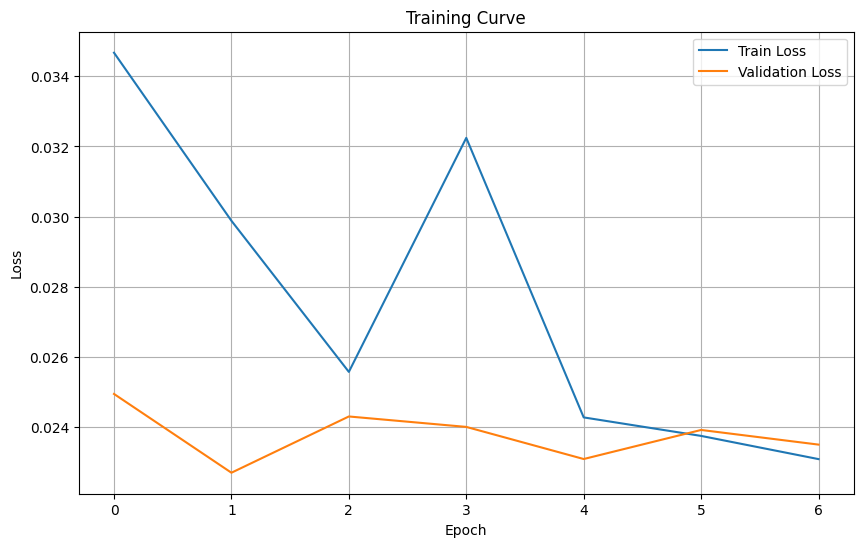

79/79 [==============================] - 0s 3ms/step - loss: 0.0227

Final Validation Loss: 0.02269701100885868


In [45]:
# %% [cell]
# 7) Train the Model and Plot the Training Curve

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=callbacks
)

# Plot the training curve
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Curve')
plt.legend()
plt.grid(True)
plt.show()

val_loss = model.evaluate(val_dataset)
print("\nFinal Validation Loss:", val_loss)
